In [1]:
# !git clone https://github.com/akmalzakia/yolo-test.git
# !git clone --depth 1 https://github.com/ultralytics/ultralytics.git

In [2]:
# %cd ultralytics
# !pip install -q -e .

In [3]:
# import wandb

# wandb.login()

In [4]:
# SET PATH
dataset_path = 'D:/deep-learning/datasets/cctsdb2021-full'
yolo_repo = ".."
project_name = "YOLOv8s Traffic Detection"
output_path = f"./runs/detect/{project_name}"
yolo_mod_path = f'{yolo_repo}/custom'
ultralytics_path = "D:/deep-learning/ultralytics/ultralytics"

yolo_path = f'{yolo_repo}/cfg/yolov8-p2_spconv.yaml'
model_name = "YOLOv8s + SPConvMulti + P2"

In [5]:
import shutil

# conv.py -- ultralytics/nn/modules/
shutil.copy(f'{yolo_mod_path}/nn/modules/conv.py', 
            f'{ultralytics_path}/nn/modules/conv.py')

# block.py -- ultralytics/nn/modules/
shutil.copy(f'{yolo_mod_path}/nn/modules/block.py', 
            f'{ultralytics_path}/nn/modules/block.py')

# __init__.py -- ultralytics/nn/modules/
shutil.copy(f'{yolo_mod_path}/nn/modules/__init__.py', 
            f'{ultralytics_path}/nn/modules/__init__.py')

# spconv.py -- ultralytics/nn/
shutil.copy(f'{yolo_mod_path}/nn/modules/spconv.py',
            f'{ultralytics_path}/nn/modules/spconv.py')

# tasks.py -- ultralytics/nn/
shutil.copy(f'{yolo_mod_path}/nn/tasks.py', 
            f'{ultralytics_path}/nn/tasks.py')

# loss.py -- ultralytics/utils/
shutil.copy(f'{yolo_mod_path}/utils/loss.py',
            f'{ultralytics_path}/utils/loss.py')

# loss_logger.py -- ultralytics/utils/
shutil.copy(f'{yolo_mod_path}/utils/loss_logger.py',
            f'{ultralytics_path}/utils/loss_logger.py')

'D:/deep-learning/ultralytics/ultralytics/utils/loss_logger.py'

In [6]:
from ultralytics import YOLO
from ultralytics.utils import SETTINGS
SETTINGS['wandb'] = True
SETTINGS['tensorboard'] = True

In [7]:
configs = {
    "data": dataset_path,
    "epochs": 100,
    "imgsz": 640,
    "batch": 16,
    "amp": True,
    "device": "cuda:0",
    "optimizer": 'SGD',
    "lr0": 0.01,
    "workers": 4,
    "patience": 15,
    "val": True,
    "project": project_name
}

In [8]:
import os
os.environ['YOLO_IOU_LOSS']        = 'CIoU'
os.environ['YOLO_IOU_MONOTONOUS']  = 'none'
# os.environ['YOLO_IOU_INNER_RATIO'] = '0.7'

## YOLO Training

In [9]:
# from wandb.integration.ultralytics import add_wandb_callback
from ultralytics.utils.loss_logger import log_loss_config
from ultralytics.nn.modules.spconv import SPConvFreezeCallback

# with wandb.init(project=configs["project"], name=model_name, job_type="train") as run:
model = YOLO(yolo_path, task='detect', verbose=True)
model.add_callback('on_pretrain_routine_end', log_loss_config)
SPConvFreezeCallback.attach(model)

WARNING no model scale passed. Assuming scale='s'.

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    459776  ultralytics.nn.modules.spconv.SPConvC2f      [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2   1837056  ultralytics.nn.modules.spconv.SPConvC2f      [256, 256, 2, True]           
  7                  -1  1    164608

In [10]:
model_results = model.train(
    data    = configs["data"],
    epochs  = configs["epochs"],
    imgsz   = configs["imgsz"],
    batch   = configs["batch"], 
    device  = configs["device"],
    amp     = configs["amp"],
    workers      = configs["workers"],
    optimizer    = configs["optimizer"],
    lr0          = configs["lr0"],
    project      = configs["project"],
    name         = f"{model_name}/train",
    exist_ok     = True,
    save_period  = 10,
    verbose      = True,
    patience     = configs["patience"],
    val          = configs["val"]
)

New https://pypi.org/project/ultralytics/8.4.56 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.51  Python-3.14.4 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:/deep-learning/datasets/cctsdb2021-full, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=../cfg/yolov8-p2_spconv.yaml, momentum=0.9

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: zakiasmara11 (azaki-its-team) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Overriding model.yaml nc=80 with nc=3
WARNING no model scale passed. Assuming scale='s'.

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.spconv.SPConvC2f      [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.spconv.SPConvC2f      [256, 256, 2, True]          

c:\Users\s2\anaconda3\envs\deep-learning\Lib\site-packages\torch\jit\_trace.py:1022: UserWarning: The input to trace is already a ScriptModule, tracing it is a no-op. Returning the object as is.
  traced_func = _trace_impl(


      1/100      4.83G       3.29      4.128      2.421          5        640: 100% ━━━━━━━━━━━━ 1023/1023 3.7it/s 4:38<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 6.2it/s 7.5s0.2s
                   all       1500       3228      0.469      0.188      0.156     0.0732

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      5.01G      1.862      1.774      1.386         11        640: 100% ━━━━━━━━━━━━ 1023/1023 3.7it/s 4:34<0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 6.2it/s 7.6s0.2s
                   all       1500       3228      0.578      0.405      0.417      0.205

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100      5.01G      1.585      1.323      1.222          6        640: 100% ━━━━━━━━━━━━ 1023/1023 3.8it/s 4:32<0.5s
                 Class     

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


wandb: WARNING Tried to log to step 94 that is less than the current step 95. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 94 that is less than the current step 95. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 94 that is less than the current step 95. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 94 that is less than the current step 95. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 94 that is less than the current step 95. Steps must be monotonically increasing, so this data will be ignored. See https://wand

lr/pg0,▆████▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▁
lr/pg1,▃▆█████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁
lr/pg2,█▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
metrics/mAP50(B),▁▄▆▇▇▇▇█████████████████████████████████
metrics/mAP50-95(B),▁▅▆▇▇▇█▇▇███████████████████████████████
metrics/precision(B),▁▅▆▇▇▇▇██▇▇██▇▇▇██▇█████▇█████▇▇▇▇▇▇▇▇▇▇
metrics/recall(B),▁▄▅▆▇▇▇▇▇▇▇████████▇████████████████████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


## Test Set Validation

In [10]:
import os

# Resolve best-weight paths
weights = f"{output_path}/{model_name}/train/weights/best.pt"
CONF_THRES   = 0.001
IOU_THRES    = 0.7

# Load best checkpoints
best_weights = YOLO(weights)

# Run validation on the test split
val_model = best_weights.val(
    data   = f"{configs["data"]}/dataset.yaml",
    split  = "test",
    imgsz  = configs["imgsz"],
    batch  = configs["batch"],
    device = configs["device"],
    plots  = True,
    project = configs["project"],
    name    = f"{model_name}/test",
    exist_ok = True,
    verbose  = True,
    conf    = CONF_THRES,
    iou     = IOU_THRES
)

print(f"\n=== {model_name} — Test Set Results ===")
print(f"  mAP50   : {val_model.box.map50:.4f}")
print(f"  mAP50-95: {val_model.box.map:.4f}")
print(f"  Precision: {val_model.box.mp:.4f}")
print(f"  Recall   : {val_model.box.mr:.4f}")

Ultralytics 8.4.51  Python-3.14.4 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLOv8-p2_spconv summary (fused): 68 layers, 3,302,169 parameters, 0 gradients, 29.8 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1744.6842.7 MB/s, size: 155.9 KB)
val: Scanning D:\deep-learning\datasets\cctsdb2021-full\labels\test.cache... 1500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1500/1500 331.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 8.7it/s 10.8s0.1s
                   all       1500       3228       0.87      0.774      0.817      0.532
             mandatory        525        718      0.853      0.708      0.734      0.485
           prohibitory       1043       2177      0.911      0.746      0.841      0.566
               warning        288        333      0.845      0.868      0.876      0.546
Speed: 0.4ms preprocess, 4.3ms inference, 0.0ms loss, 0.6ms postprocess per image


# Analysis

## Setup

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import time
import yaml
import torch
import glob
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = sns.color_palette("tab10")

with open(f"{configs['data']}/dataset.yaml") as f:
    _cfg = yaml.safe_load(f)
CLASS_NAMES = _cfg.get("names", [])
NC = len(CLASS_NAMES)
print(f"Classes ({NC}): {CLASS_NAMES}")

Classes (3): ['mandatory', 'prohibitory', 'warning']


In [12]:
train_dir = Path(output_path) / model_name / 'train'

assert Path(weights).exists(), f'Weights not found: {weights}'
print(f'Run     : {model_name}')
print(f'Weights : {weights}')

analysis_dir = train_dir / 'post_analysis'
analysis_dir.mkdir(exist_ok=True)
print(f'Outputs : {analysis_dir}')

COL = {
    'epoch'    : 'epoch',
    'box_loss' : 'train/box_loss',
    'cls_loss' : 'train/cls_loss',
    'dfl_loss' : 'train/dfl_loss',
    'val_box'  : 'val/box_loss',
    'val_cls'  : 'val/cls_loss',
    'map50'    : 'metrics/mAP50(B)',
    'map5095'  : 'metrics/mAP50-95(B)',
    'precision': 'metrics/precision(B)',
    'recall'   : 'metrics/recall(B)',
}

Run     : YOLOv8s + SPConvMulti + P2
Weights : ./runs/detect/YOLOv8s Traffic Detection/YOLOv8s + SPConvMulti + P2/train/weights/best.pt
Outputs : runs\detect\YOLOv8s Traffic Detection\YOLOv8s + SPConvMulti + P2\train\post_analysis


## Training Curves

Epochs logged: 94
Best mAP@0.5 : 0.8176  (epoch 60)
Best mAP@0.5:0.95 : 0.5290


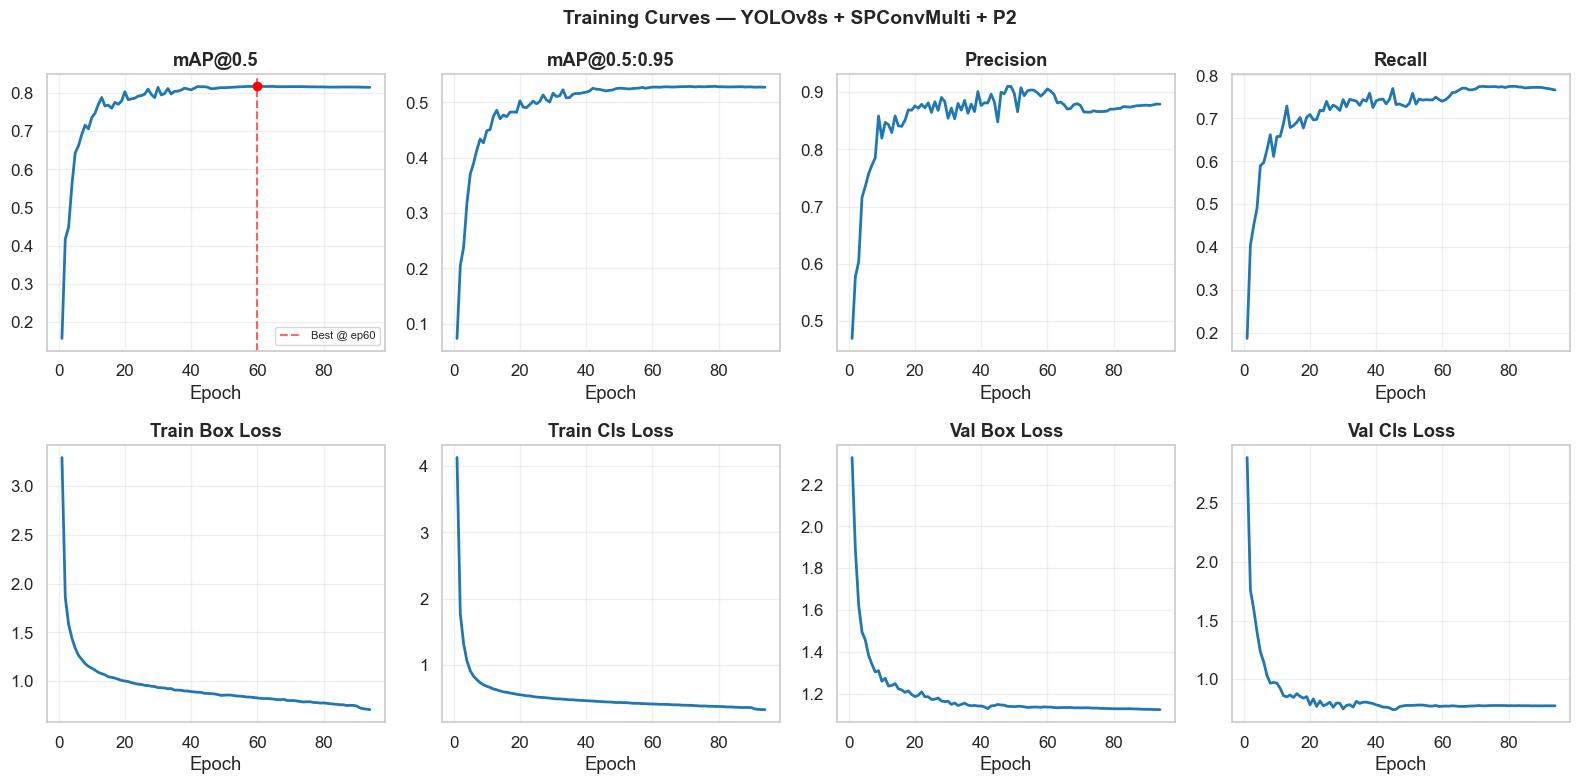

In [13]:
csv_path = train_dir / 'results.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()
print(f'Epochs logged: {len(df)}')

_metrics = [
    ('map50',     'mAP@0.5'),
    ('map5095',   'mAP@0.5:0.95'),
    ('precision', 'Precision'),
    ('recall',    'Recall'),
    ('box_loss',  'Train Box Loss'),
    ('cls_loss',  'Train Cls Loss'),
    ('val_box',   'Val Box Loss'),
    ('val_cls',   'Val Cls Loss'),
]

ncols = 4
nrows = (len(_metrics) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for ax, (key, title) in zip(axes, _metrics):
    col = COL.get(key, key)
    if col in df.columns:
        ax.plot(df[COL['epoch']], df[col], color=PALETTE[0], linewidth=2)
        # mark best mAP epoch
        if key == 'map50':
            best_e = df.loc[df[col].idxmax(), COL['epoch']]
            best_v = df[col].max()
            ax.axvline(best_e, color='red', linestyle='--', alpha=0.6, label=f'Best @ ep{int(best_e)}')
            ax.scatter([best_e], [best_v], color='red', zorder=5)
            ax.legend(fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)

for ax in axes[len(_metrics):]:
    ax.set_visible(False)
plt.suptitle(f'Training Curves — {model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(analysis_dir / 'training_curves.png', dpi=150, bbox_inches='tight')
print(f'Best mAP@0.5 : {df[COL["map50"]].max():.4f}  (epoch {int(best_e)})')
print(f'Best mAP@0.5:0.95 : {df[COL["map5095"]].max():.4f}')
plt.show()

## PR & F1 Curves

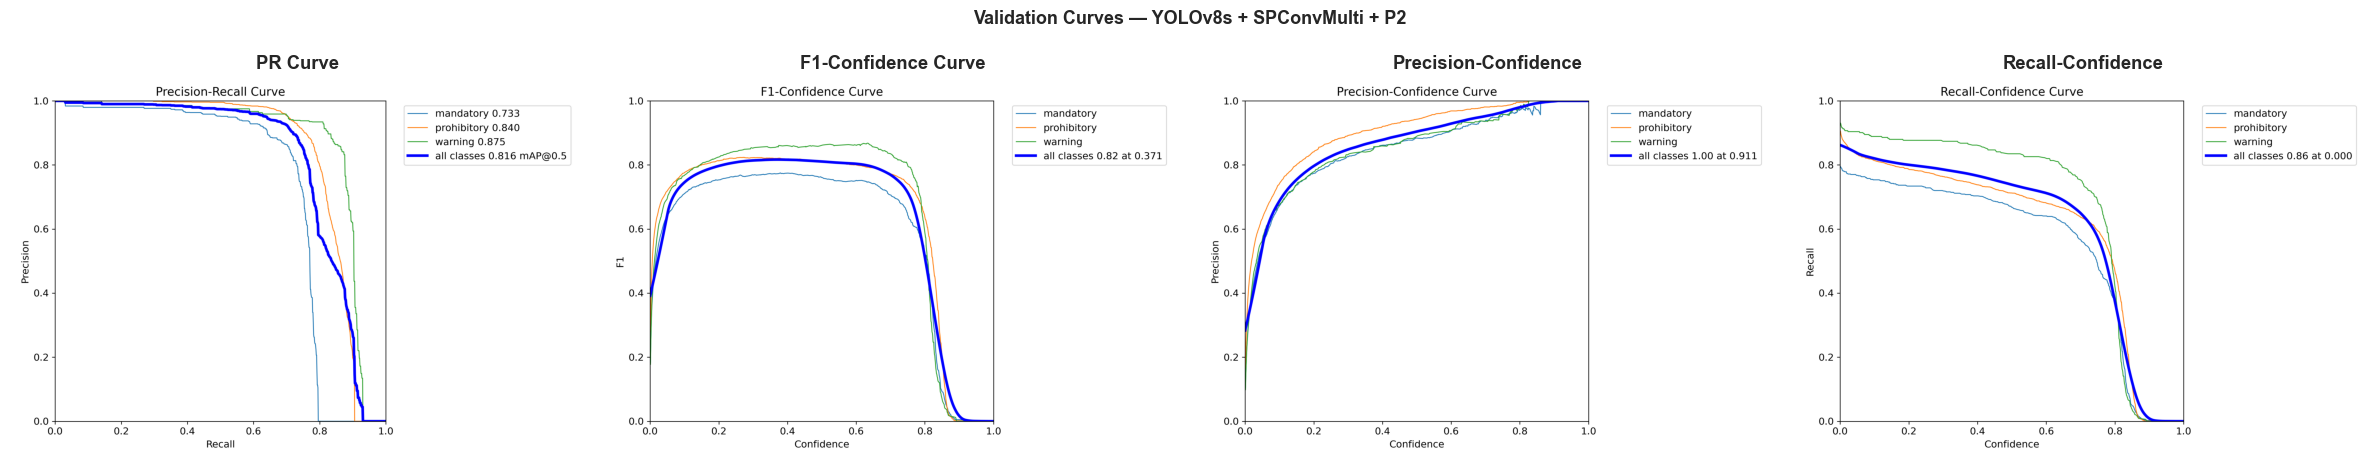

In [14]:
_curve_files = {
    'BoxPR_curve.png' : 'PR Curve',
    'BoxF1_curve.png' : 'F1-Confidence Curve',
    'BoxP_curve.png'  : 'Precision-Confidence',
    'BoxR_curve.png'  : 'Recall-Confidence',
}

found = [(fn, title) for fn, title in _curve_files.items()
         if (train_dir / fn).exists()]

if found:
    fig, axes = plt.subplots(1, len(found), figsize=(6 * len(found), 5))
    if len(found) == 1: axes = [axes]
    for ax, (fn, title) in zip(axes, found):
        img = np.array(Image.open(train_dir / fn))
        ax.imshow(img)
        ax.set_title(title, fontweight='bold')
        ax.axis('off')
    plt.suptitle(f'Validation Curves — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(analysis_dir / 'val_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('[skip] No curve images found in train folder — run model.val() first.')


## Per-Class AP

mAP@0.5      : 0.8166
mAP@0.5:0.95 : 0.5322
Precision    : 0.8696
Recall       : 0.7739

Per-class AP@0.5:
  mandatory           : 0.7336
  prohibitory         : 0.8407


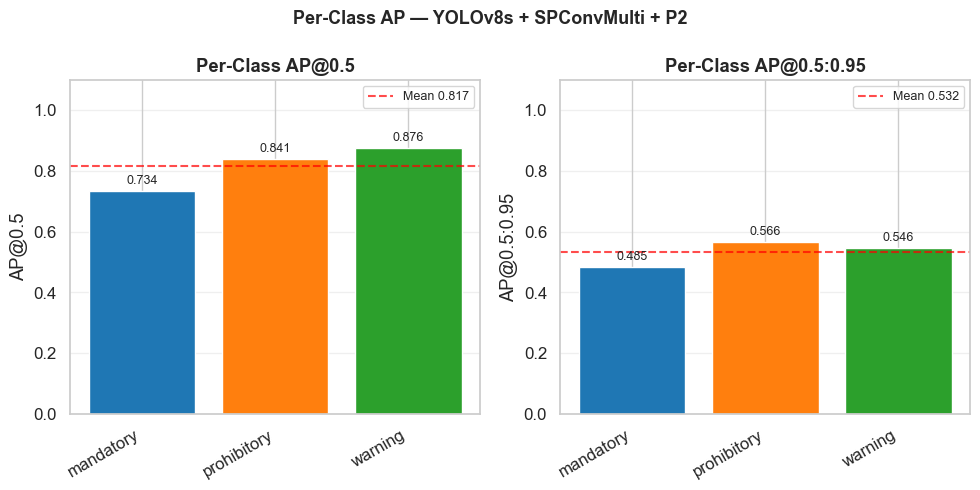

In [15]:
ap50  = dict(zip(CLASS_NAMES, val_model.box.ap50))
maps  = dict(zip(CLASS_NAMES, val_model.box.maps))
map50_overall   = val_model.box.map50
map5095_overall = val_model.box.map

print(f'mAP@0.5      : {map50_overall:.4f}')
print(f'mAP@0.5:0.95 : {map5095_overall:.4f}')
print(f'Precision    : {val_model.box.mp:.4f}')
print(f'Recall       : {val_model.box.mr:.4f}')
print()
print('Per-class AP@0.5:')
for cls, v in ap50.items():
    print(f'  {cls:20s}: {v:.4f}')

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(max(10, NC * 1.4), 5))
x = np.arange(NC)
for ax, (vals_dict, metric_label) in zip(axes,
        [(ap50, 'AP@0.5'), (maps, 'AP@0.5:0.95')]):
    vals = [vals_dict[c] for c in CLASS_NAMES]
    bars = ax.bar(x, vals, color=PALETTE[:NC], edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
    ax.set_ylabel(metric_label)
    ax.set_ylim(0, 1.1)
    ax.set_title(f'Per-Class {metric_label}', fontweight='bold')
    ax.axhline(sum(vals)/len(vals), color='red', linestyle='--',
               alpha=0.7, label=f'Mean {sum(vals)/len(vals):.3f}')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Per-Class AP — {model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(analysis_dir / 'perclass_ap.png', dpi=150, bbox_inches='tight')
plt.show()


## Model Specifications

YOLOv8-p2_spconv summary: 120 layers, 4,763,936 parameters, 3,739,920 gradients, 39.4 GFLOPs
Parameters : 4.76 M
FLOPs      : 39.4 G
Inference  : 108.1 FPS  (9.25 ms/img)  on cuda:0


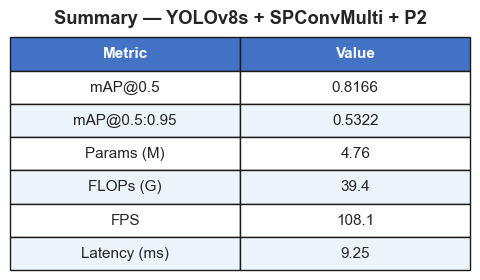

In [16]:
from ultralytics.utils.torch_utils import model_info

info = model_info(model.model, imgsz=configs["imgsz"], verbose=True)
params_m = round(info[1] / 1e6, 2)
flops_g = round(info[3], 1)
print(f"Parameters : {params_m} M")
print(f"FLOPs      : {flops_g} G")

# FPS benchmark
det = model.model.to(configs["device"]).eval()
dummy = torch.zeros(1, 3, configs["imgsz"], configs["imgsz"]).to(configs["device"])
N_WARM, N_RUNS = 10, 100

with torch.no_grad():
    for _ in range(N_WARM):
        det(dummy)

if "cuda" in configs["device"]:
    torch.cuda.synchronize()
t0 = time.perf_counter()
with torch.no_grad():
    for _ in range(N_RUNS):
        det(dummy)
if "cuda" in configs["device"]:
    torch.cuda.synchronize()
elapsed = time.perf_counter() - t0
fps = round(N_RUNS / elapsed, 1)
lat = round(elapsed / N_RUNS * 1000, 2)

print(f"Inference  : {fps} FPS  ({lat} ms/img)  on {configs['device']}")

# Summary card
fig, ax = plt.subplots(figsize=(5, 3))
ax.axis("off")
rows = [
    ["Metric", "Value"],
    ["mAP@0.5", f"{map50_overall:.4f}"],
    ["mAP@0.5:0.95", f"{map5095_overall:.4f}"],
    ["Params (M)", str(params_m)],
    ["FLOPs (G)", str(flops_g)],
    ["FPS", str(fps)],
    ["Latency (ms)", str(lat)],
]
tbl = ax.table(
    cellText=rows[1:],
    colLabels=rows[0],
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#4472C4")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#EBF3FB")
plt.title(f"Summary — {model_name}", fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig(analysis_dir / "summary_card.png", dpi=150, bbox_inches="tight")
plt.show()


## Detection Visualization

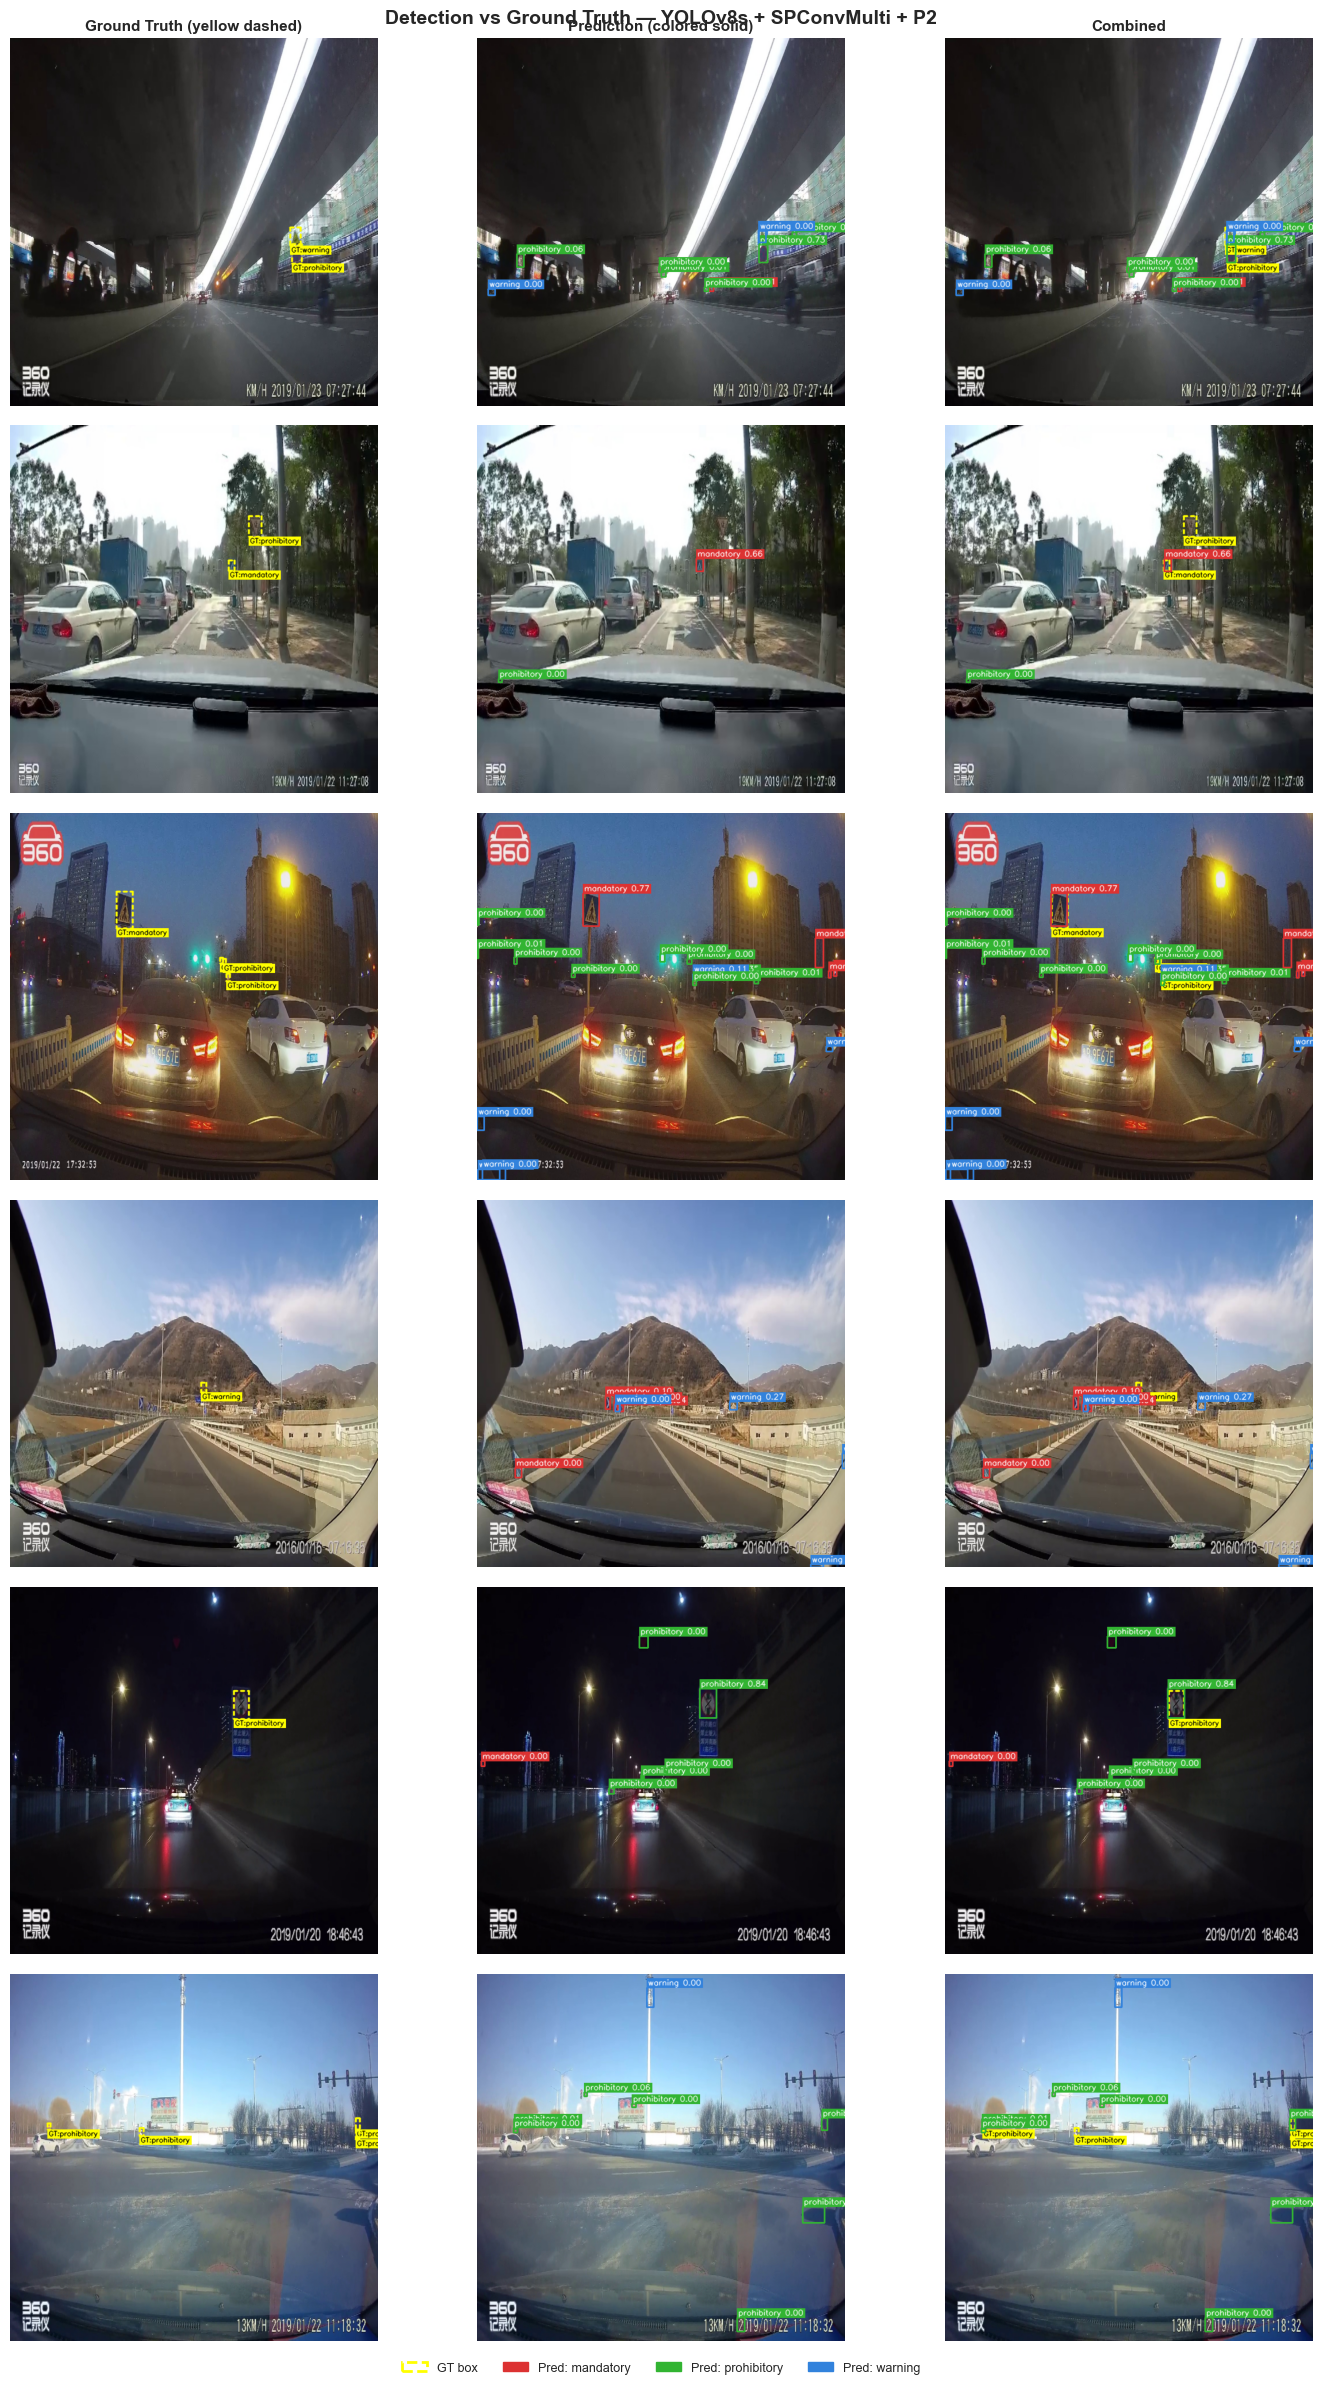

In [17]:
VAL_IMG_DIR = Path(dataset_path) / "images" / "test"
VAL_LBL_DIR = Path(dataset_path) / "labels" / "test"


def get_val_images(n=8, seed=42):
    imgs = sorted(
        glob.glob(str(VAL_IMG_DIR / "*.jpg")) + glob.glob(str(VAL_IMG_DIR / "*.png"))
    )
    rng = np.random.default_rng(seed)
    return rng.choice(imgs, min(n, len(imgs)), replace=False).tolist()


BOX_COLORS = [
    (220, 50, 50),
    (50, 180, 50),
    (50, 130, 220),
    (200, 150, 20),
    (180, 50, 200),
]
GT_COLOR = (255, 255, 0)  # yellow for all GT boxes (dashed style via gap trick)
GT_DASH = 6  # dash gap length in pixels


def draw_gt_boxes(img_rgb, img_path):
    """
    Draw ground-truth boxes from the paired YOLO .txt label file.
    Style: yellow dashed rectangle + class name (no confidence).
    """
    canvas = img_rgb.copy()
    h, w = canvas.shape[:2]
    stem = Path(img_path).stem
    lbl_path = VAL_LBL_DIR / f"{stem}.txt"
    if not lbl_path.exists():
        return canvas, 0

    gt_count = 0
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])
            x1 = int((cx - bw / 2) * w)
            y1 = int((cy - bh / 2) * h)
            x2 = int((cx + bw / 2) * w)
            y2 = int((cy + bh / 2) * h)

            # Dashed rectangle (draw short segments along each edge)
            for edge in ["top", "bottom", "left", "right"]:
                if edge == "top":
                    pts = [(x, y1) for x in range(x1, x2, GT_DASH * 2)]
                    pairs = [(p, (min(p[0] + GT_DASH, x2), y1)) for p in pts]
                elif edge == "bottom":
                    pts = [(x, y2) for x in range(x1, x2, GT_DASH * 2)]
                    pairs = [(p, (min(p[0] + GT_DASH, x2), y2)) for p in pts]
                elif edge == "left":
                    pts = [(x1, y) for y in range(y1, y2, GT_DASH * 2)]
                    pairs = [(p, (x1, min(p[1] + GT_DASH, y2))) for p in pts]
                else:
                    pts = [(x2, y) for y in range(y1, y2, GT_DASH * 2)]
                    pairs = [(p, (x2, min(p[1] + GT_DASH, y2))) for p in pts]
                for p1, p2 in pairs:
                    cv2.line(canvas, p1, p2, GT_COLOR, 2, cv2.LINE_AA)

            # Label (bottom-left corner, below the box)
            name = CLASS_NAMES[cls] if cls < NC else str(cls)
            lbl = f"GT:{name}"
            (tw, th), _ = cv2.getTextSize(lbl, cv2.FONT_HERSHEY_SIMPLEX, 0.40, 1)
            ty = min(y2 + th + 4, h - 2)
            cv2.rectangle(
                canvas, (x1, ty - th - 4), (x1 + tw + 4, ty + 2), GT_COLOR, -1
            )
            cv2.putText(
                canvas,
                lbl,
                (x1 + 2, ty - 2),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.40,
                (0, 0, 0),
                1,
                cv2.LINE_AA,
            )
            gt_count += 1

    return canvas, gt_count


def draw_pred_boxes(img_rgb, result):
    """Draw predicted boxes: solid colored rectangle + class + confidence."""
    canvas = img_rgb.copy()
    if result.boxes is None:
        return canvas
    for b in result.boxes:
        if float(b.conf) < CONF_THRES:
            continue
        cls = int(b.cls)
        x1, y1, x2, y2 = map(int, b.xyxy[0].tolist())
        color = BOX_COLORS[cls % len(BOX_COLORS)]
        cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)
        name = CLASS_NAMES[cls] if cls < NC else str(cls)
        lbl = f"{name} {float(b.conf):.2f}"
        (tw, th), _ = cv2.getTextSize(lbl, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(canvas, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
        cv2.putText(
            canvas,
            lbl,
            (x1 + 2, y1 - 4),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )
    return canvas


def draw_combined(img_rgb, result, img_path):
    """GT boxes (yellow dashed) + predicted boxes (colored solid) on the same image."""
    canvas, _ = draw_gt_boxes(img_rgb, img_path)  # GT first (background layer)
    canvas = draw_pred_boxes(canvas, result)  # predictions on top
    return canvas


# ── Plot: 3 columns per image (GT | Prediction | Combined) ─────────────────
SAMPLE_IMGS = get_val_images(n=6)  # 6 images × 3 columns fits well on screen
model = YOLO(str(weights))

n_imgs = len(SAMPLE_IMGS)
fig, axes = plt.subplots(n_imgs, 3, figsize=(15, 4 * n_imgs))
if n_imgs == 1:
    axes = axes[np.newaxis, :]

col_titles = ["Ground Truth (yellow dashed)", "Prediction (colored solid)", "Combined"]
for col_i, t in enumerate(col_titles):
    axes[0, col_i].set_title(t, fontweight="bold", fontsize=11)

for row, img_path in enumerate(SAMPLE_IMGS):
    img_bgr = cv2.resize(cv2.imread(img_path), (configs["imgsz"], configs["imgsz"]))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    result = model(
        img_bgr, conf=CONF_THRES, iou=IOU_THRES, imgsz=configs["imgsz"], verbose=False
    )[0]

    gt_canvas, n_gt = draw_gt_boxes(img_rgb, img_path)
    pred_canvas = draw_pred_boxes(img_rgb, result)
    combined_canvas = draw_combined(img_rgb, result, img_path)

    n_pred = len(result.boxes) if result.boxes else 0

    axes[row, 0].imshow(gt_canvas)
    axes[row, 0].set_ylabel(
        Path(img_path).name, fontsize=7, rotation=0, labelpad=90, va="center"
    )
    axes[row, 1].imshow(pred_canvas)
    axes[row, 2].imshow(combined_canvas)

    axes[row, 0].set_xlabel(f"GT: {n_gt}", fontsize=9)
    axes[row, 1].set_xlabel(f"Pred: {n_pred}", fontsize=9)

    # TP / FP / FN quick count for the combined subtitle
    gt_boxes_px = []
    h_i, w_i = img_bgr.shape[:2]
    stem = Path(img_path).stem
    lbl_path = VAL_LBL_DIR / f"{stem}.txt"
    if lbl_path.exists():
        with open(lbl_path) as lf:
            for line in lf:
                p = line.strip().split()
                if len(p) < 5:
                    continue
                cls, cx, cy, bw, bh = int(p[0]), *map(float, p[1:5])
                gt_boxes_px.append(
                    (
                        cls,
                        int((cx - bw / 2) * w_i),
                        int((cy - bh / 2) * h_i),
                        int((cx + bw / 2) * w_i),
                        int((cy + bh / 2) * h_i),
                    )
                )

    matched = set()
    tp_i = fp_i = 0
    if result.boxes:
        for b in result.boxes:
            if float(b.conf) < CONF_THRES:
                continue
            pcls = int(b.cls)
            px1, py1, px2, py2 = map(int, b.xyxy[0].tolist())
            best_iou, best_idx = 0, -1
            for gi, (gcls, gx1, gy1, gx2, gy2) in enumerate(gt_boxes_px):
                ix1, iy1 = max(px1, gx1), max(py1, gy1)
                ix2, iy2 = min(px2, gx2), min(py2, gy2)
                inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
                a1 = (px2 - px1) * (py2 - py1)
                a2 = (gx2 - gx1) * (gy2 - gy1)
                iou = inter / (a1 + a2 - inter + 1e-6)
                if iou > best_iou:
                    best_iou, best_idx = iou, gi
            if best_iou >= 0.5 and best_idx not in matched:
                matched.add(best_idx)
                tp_i += 1
            else:
                fp_i += 1
    fn_i = len(gt_boxes_px) - len(matched)
    axes[row, 2].set_xlabel(
        f"TP:{tp_i}  FP:{fp_i}  FN:{fn_i}",
        fontsize=9,
        color="black",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="lightyellow", alpha=0.8),
    )

    for ax in axes[row]:
        ax.axis("off")

# Legend
legend_handles = [
    mpatches.Patch(
        facecolor="none",
        edgecolor=(1, 1, 0),
        linewidth=2,
        linestyle="--",
        label="GT box",
    ),
]
for i, name in enumerate(CLASS_NAMES):
    c = tuple(v / 255 for v in BOX_COLORS[i % len(BOX_COLORS)])
    legend_handles.append(mpatches.Patch(color=c, label=f"Pred: {name}"))

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(legend_handles),
    fontsize=9,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)

plt.suptitle(
    f"Detection vs Ground Truth — {model_name}", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig(analysis_dir / "detection_samples.png", dpi=150, bbox_inches="tight")
plt.show()


## GradCAM

In [18]:
# ── GradCAM helpers ────────────────────────────────────────────────────
class YOLOv8GradCAMWrapper(torch.nn.Module):
    def __init__(self, detection_model):
        super().__init__()
        self.model = detection_model

    def forward(self, x):
        return self.model._predict_once(x)


def _run_inference(img_bgr):
    """Return (boxes_xyxy, confs, cls_ids) from YOLO inference."""
    m = YOLO(str(weights))
    r = m(
        img_bgr, conf=CONF_THRES, iou=IOU_THRES, imgsz=configs["imgsz"], verbose=False
    )[0]
    boxes, confs, cls_ids = [], [], []
    if r.boxes is not None:
        for b in r.boxes:
            boxes.append(b.xyxy[0].cpu().numpy().astype(int))
            confs.append(float(b.conf))
            cls_ids.append(int(b.cls))
    return boxes, confs, cls_ids


def _get_gt_boxes_px(img_path, img_w=configs["imgsz"], img_h=configs["imgsz"]):
    """
    Read YOLO .txt label for img_path and return
    list of (cls, x1, y1, x2, y2) in pixel coords scaled to img_w x img_h.
    """
    stem = Path(img_path).stem
    lbl_path = VAL_LBL_DIR / f"{stem}.txt"
    gt = []
    if not lbl_path.exists():
        return gt
    with open(lbl_path) as f:
        for line in f:
            p = line.strip().split()
            if len(p) < 5:
                continue
            cls, cx, cy, bw, bh = int(p[0]), *map(float, p[1:5])
            x1 = int((cx - bw / 2) * img_w)
            y1 = int((cy - bh / 2) * img_h)
            x2 = int((cx + bw / 2) * img_w)
            y2 = int((cy + bh / 2) * img_h)
            gt.append((cls, x1, y1, x2, y2))
    return gt


def _draw_pred_on(img_rgb_u8, boxes, confs, cls_ids):
    """Solid colored boxes + label above — predicted detections."""
    canvas = img_rgb_u8.copy()
    for (x1, y1, x2, y2), conf, cls in zip(boxes, confs, cls_ids):
        color = BOX_COLORS[cls % len(BOX_COLORS)]
        cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)
        name = CLASS_NAMES[cls] if cls < NC else str(cls)
        lbl = f"{name} {conf:.2f}"
        (tw, th), _ = cv2.getTextSize(lbl, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(canvas, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
        cv2.putText(
            canvas,
            lbl,
            (x1 + 2, y1 - 4),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )
    return canvas


def _draw_gt_on(img_rgb_u8, gt_boxes, dash=6):
    """Yellow dashed boxes + GT label below — ground truth."""
    canvas = img_rgb_u8.copy()
    h, w = canvas.shape[:2]
    color = GT_COLOR
    for cls, x1, y1, x2, y2 in gt_boxes:
        # dashed rectangle
        for edge in ["top", "bottom", "left", "right"]:
            if edge == "top":
                segs = [(x, y1, min(x + dash, x2), y1) for x in range(x1, x2, dash * 2)]
            elif edge == "bottom":
                segs = [(x, y2, min(x + dash, x2), y2) for x in range(x1, x2, dash * 2)]
            elif edge == "left":
                segs = [(x1, y, x1, min(y + dash, y2)) for y in range(y1, y2, dash * 2)]
            else:
                segs = [(x2, y, x2, min(y + dash, y2)) for y in range(y1, y2, dash * 2)]
            for sx1, sy1, sx2, sy2 in segs:
                cv2.line(canvas, (sx1, sy1), (sx2, sy2), color, 2, cv2.LINE_AA)
        # label below the box
        name = CLASS_NAMES[cls] if cls < NC else str(cls)
        lbl = f"GT:{name}"
        (tw, th), _ = cv2.getTextSize(lbl, cv2.FONT_HERSHEY_SIMPLEX, 0.40, 1)
        ty = min(y2 + th + 4, h - 2)
        cv2.rectangle(canvas, (x1, ty - th - 4), (x1 + tw + 4, ty + 2), color, -1)
        cv2.putText(
            canvas,
            lbl,
            (x1 + 2, ty - 2),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.40,
            (0, 0, 0),
            1,
            cv2.LINE_AA,
        )
    return canvas


def _draw_both_on(img_rgb_u8, gt_boxes, pred_boxes, confs, cls_ids):
    """GT (yellow dashed, drawn first) then predictions (solid, on top)."""
    canvas = _draw_gt_on(img_rgb_u8, gt_boxes)
    canvas = _draw_pred_on(canvas, pred_boxes, confs, cls_ids)
    return canvas


def _eigencam(img_bgr, layer_idx):
    m = YOLO(str(weights))
    det = m.model.eval().to(configs["device"])
    target_layer = det.model[layer_idx]
    print(f"  [{layer_idx}] → {type(target_layer).__name__}")
    wrapped = YOLOv8GradCAMWrapper(det).to(configs["device"])
    img_rgb = cv2.cvtColor(
        cv2.resize(img_bgr, (configs["imgsz"], configs["imgsz"])), cv2.COLOR_BGR2RGB
    )
    img_f32 = img_rgb.astype(np.float32) / 255.0
    tensor = (
        torch.from_numpy(img_f32).permute(2, 0, 1).unsqueeze(0).to(configs["device"])
    )
    with EigenCAM(model=wrapped, target_layers=[target_layer]) as cam:
        gray = cam(input_tensor=tensor, targets=None)[0]
    overlay = show_cam_on_image(img_f32, gray, use_rgb=True)
    return img_rgb, overlay, gray


# ── Auto-detect last backbone C2f (one layer before SPPF) ──────────────
_det = YOLO(str(weights)).model
SPPF_IDX = next(i for i, m in enumerate(_det.model) if type(m).__name__ == "SPPF")
BACKBONE_C2F_IDX = SPPF_IDX - 1
print(f"SPPF at layer {SPPF_IDX} → using layer {BACKBONE_C2F_IDX} (last backbone C2f)")

print("Model layers:")
for i, m in enumerate(_det.model):
    marker = (
        " ← target" if i == BACKBONE_C2F_IDX else (" ← SPPF" if i == SPPF_IDX else "")
    )
    print(f"  [{i:2d}] {type(m).__name__}{marker}")

SPPF at layer 7 → using layer 6 (last backbone C2f)
Model layers:
  [ 0] Conv
  [ 1] Conv
  [ 2] C2f
  [ 3] Conv
  [ 4] SPConvC2f
  [ 5] Conv
  [ 6] SPConvC2f ← target
  [ 7] SPPF ← SPPF
  [ 8] Upsample
  [ 9] Concat
  [10] C2f
  [11] Upsample
  [12] Concat
  [13] C2f
  [14] Conv
  [15] Concat
  [16] C2f
  [17] Conv
  [18] Concat
  [19] C2f
  [20] Detect


GT boxes  : 2
Pred boxes: 10
  [4] → SPConvC2f
  [6] → SPConvC2f
  [6] → SPConvC2f
  [10] → C2f
  [13] → C2f
  [16] → C2f
  [19] → C2f


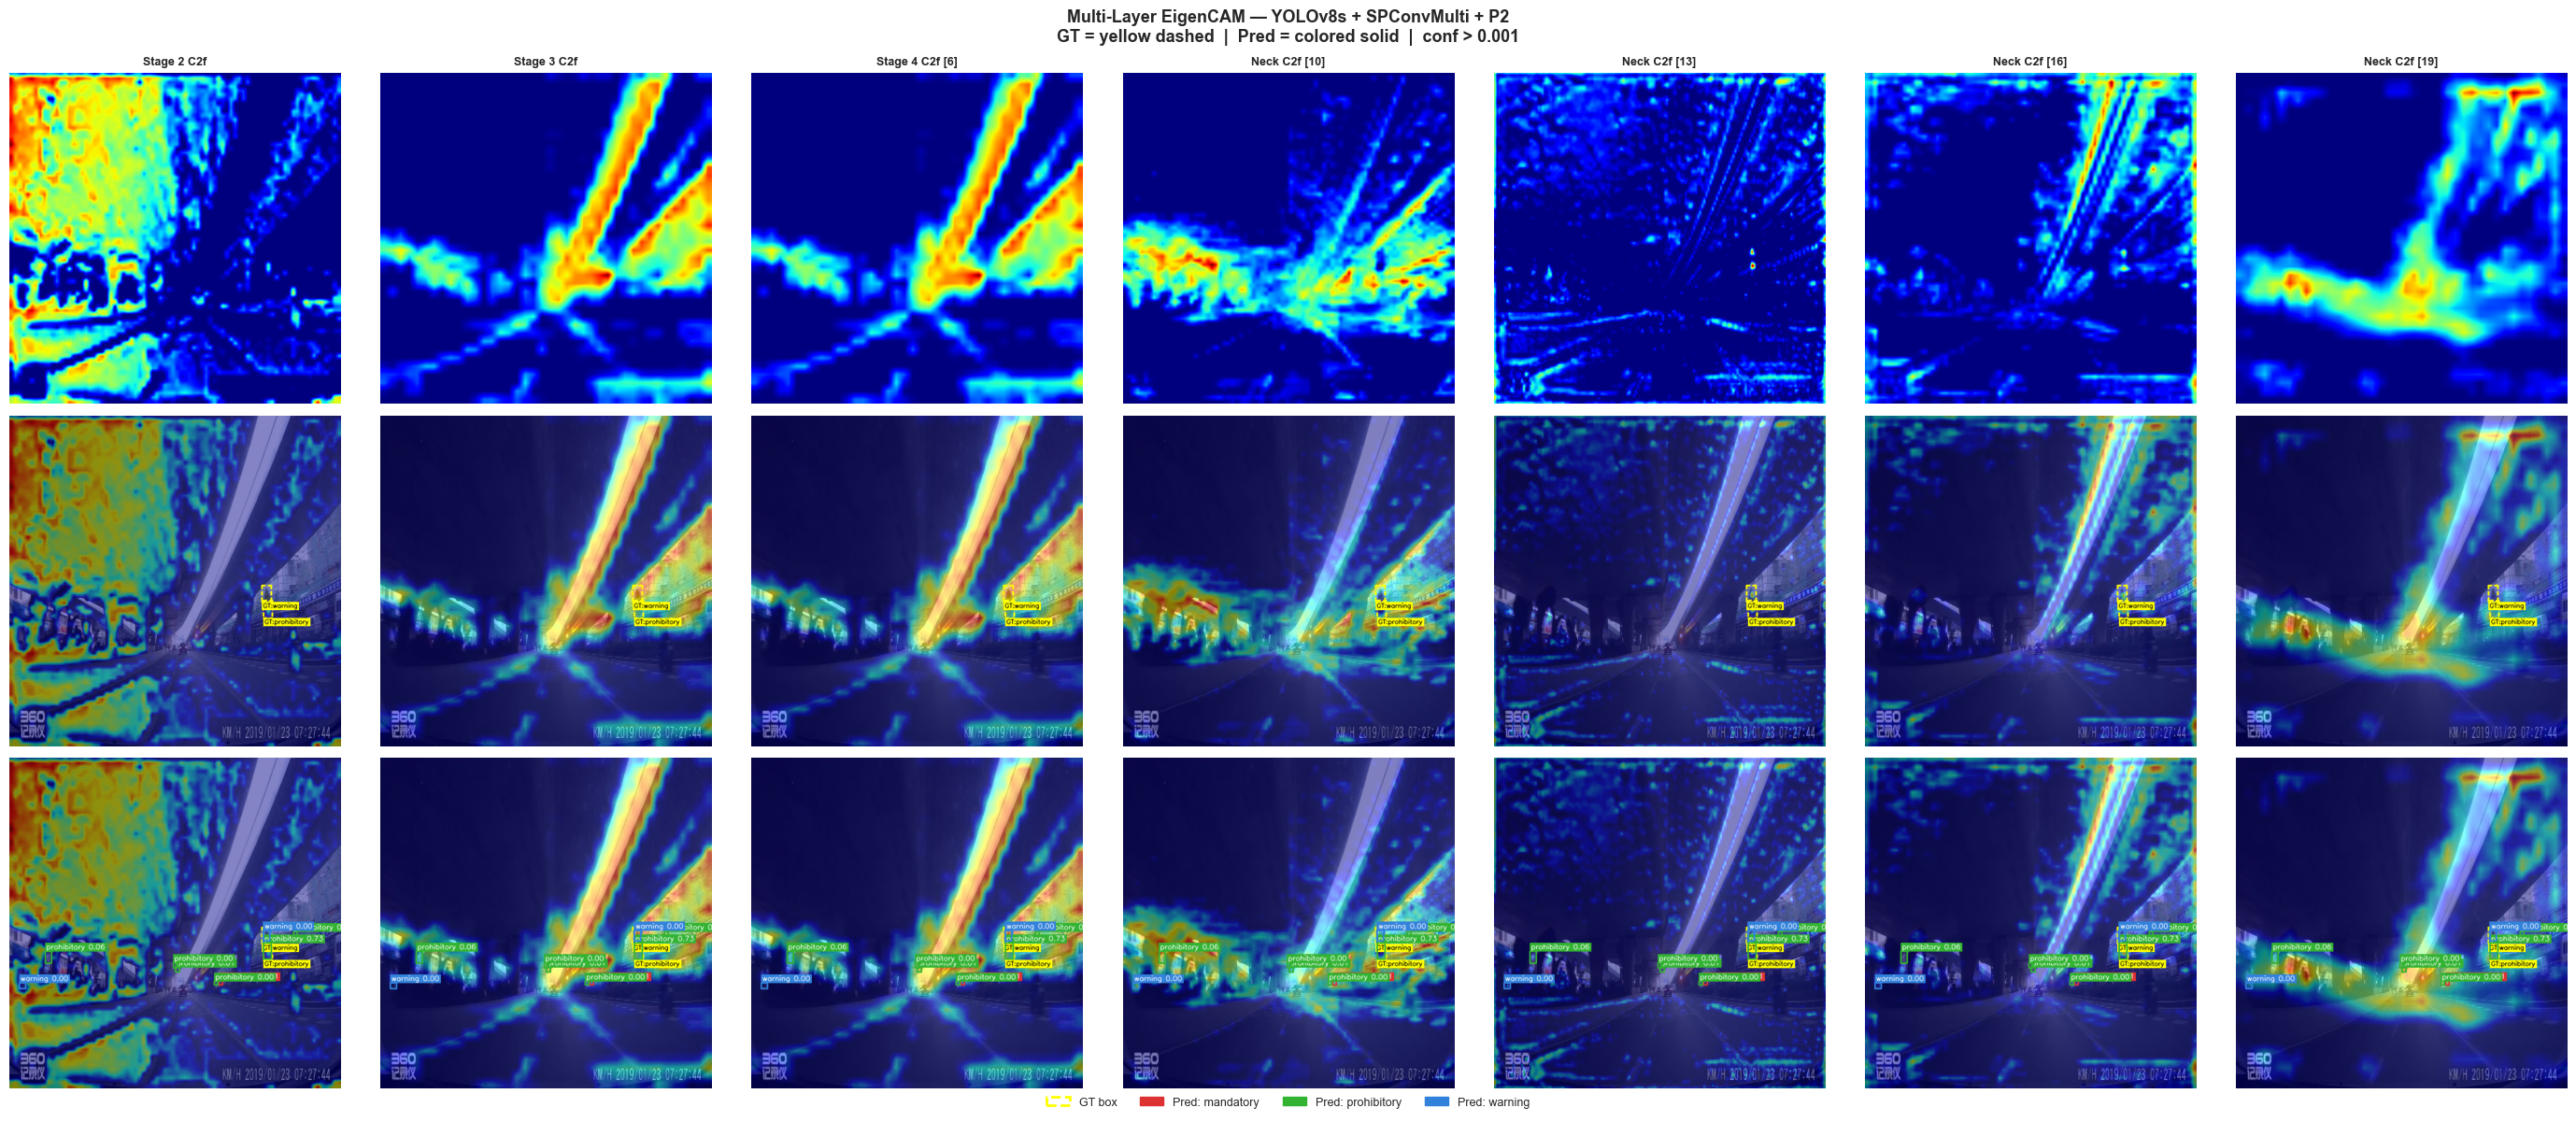

In [19]:
# ── Multi-layer EigenCAM — 3 rows × N layer columns ────────────────────────
# Row 0 : clean heatmap
# Row 1 : heatmap overlay + GT boxes   (yellow dashed)
# Row 2 : heatmap overlay + pred boxes (colored solid) + GT boxes underneath
GRADCAM_IMG = SAMPLE_IMGS[0]

img_bgr_gc = cv2.resize(cv2.imread(GRADCAM_IMG), (configs["imgsz"], configs["imgsz"]))

# run inference and load GT once — same boxes on every column
pred_boxes_gc, confs_gc, cls_gc = _run_inference(img_bgr_gc)
gt_boxes_gc = _get_gt_boxes_px(
    GRADCAM_IMG, img_w=configs["imgsz"], img_h=configs["imgsz"]
)

print(f"GT boxes  : {len(gt_boxes_gc)}")
print(f"Pred boxes: {len(pred_boxes_gc)}")

# ── build layer list (auto + manual override option) ────────────────────────
LAYERS_TO_VIZ = [
    (4, "Stage 2 C2f"),
    (6, "Stage 3 C2f"),
    (BACKBONE_C2F_IDX, f"Stage 4 C2f [{BACKBONE_C2F_IDX}]"),
]
for _i, _m in enumerate(_det.model):
    if type(_m).__name__ == "C2f" and _i > SPPF_IDX:
        LAYERS_TO_VIZ.append((_i, f"Neck C2f [{_i}]"))
    if type(_m).__name__ == "C2f_EMA" and _i > SPPF_IDX:
        LAYERS_TO_VIZ.append((_i, f"Neck C2f [{_i}]"))

n_cols = len(LAYERS_TO_VIZ)
n_rows = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

ROW_LABELS = ["Heatmap", "Overlay + GT", "Overlay + GT + Pred"]
for row_i, rl in enumerate(ROW_LABELS):
    axes[row_i, 0].set_ylabel(
        rl, fontsize=9, fontweight="bold", rotation=0, labelpad=95, va="center"
    )

for col_i, (layer_idx, layer_title) in enumerate(LAYERS_TO_VIZ):
    axes[0, col_i].set_title(layer_title, fontsize=9, fontweight="bold")
    try:
        _, overlay, gray = _eigencam(img_bgr_gc, layer_idx)

        # row 0 — clean heatmap (no boxes, best for attention reading)
        axes[0, col_i].imshow(gray, cmap="jet")

        # row 1 — overlay + GT only (shows what the model attends to vs. truth)
        axes[1, col_i].imshow(_draw_gt_on(overlay, gt_boxes_gc))

        # row 2 — overlay + GT + predictions (full picture)
        axes[2, col_i].imshow(
            _draw_both_on(overlay, gt_boxes_gc, pred_boxes_gc, confs_gc, cls_gc)
        )

    except Exception as e:
        for row_i in range(n_rows):
            axes[row_i, col_i].text(
                0.5,
                0.5,
                str(e),
                ha="center",
                va="center",
                transform=axes[row_i, col_i].transAxes,
                fontsize=7,
                wrap=True,
            )

    for row_i in range(n_rows):
        axes[row_i, col_i].axis("off")

# ── legend ───────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(
        facecolor="none",
        edgecolor=(1, 1, 0),
        linewidth=2,
        linestyle="--",
        label="GT box",
    ),
]
for i, name in enumerate(CLASS_NAMES):
    c = tuple(v / 255 for v in BOX_COLORS[i % len(BOX_COLORS)])
    legend_handles.append(mpatches.Patch(color=c, label=f"Pred: {name}"))

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(legend_handles),
    fontsize=9,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)

plt.suptitle(
    f"Multi-Layer EigenCAM — {model_name}\n"
    f"GT = yellow dashed  |  Pred = colored solid  |  conf > {CONF_THRES}",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(analysis_dir / "gradcam_multilayer.png", dpi=150, bbox_inches="tight")
plt.show()


## Error Analysis

TP=613  FP=3387  FN=65  CLS_ERR=9
Precision=0.1529  Recall=0.8923  F1=0.2611


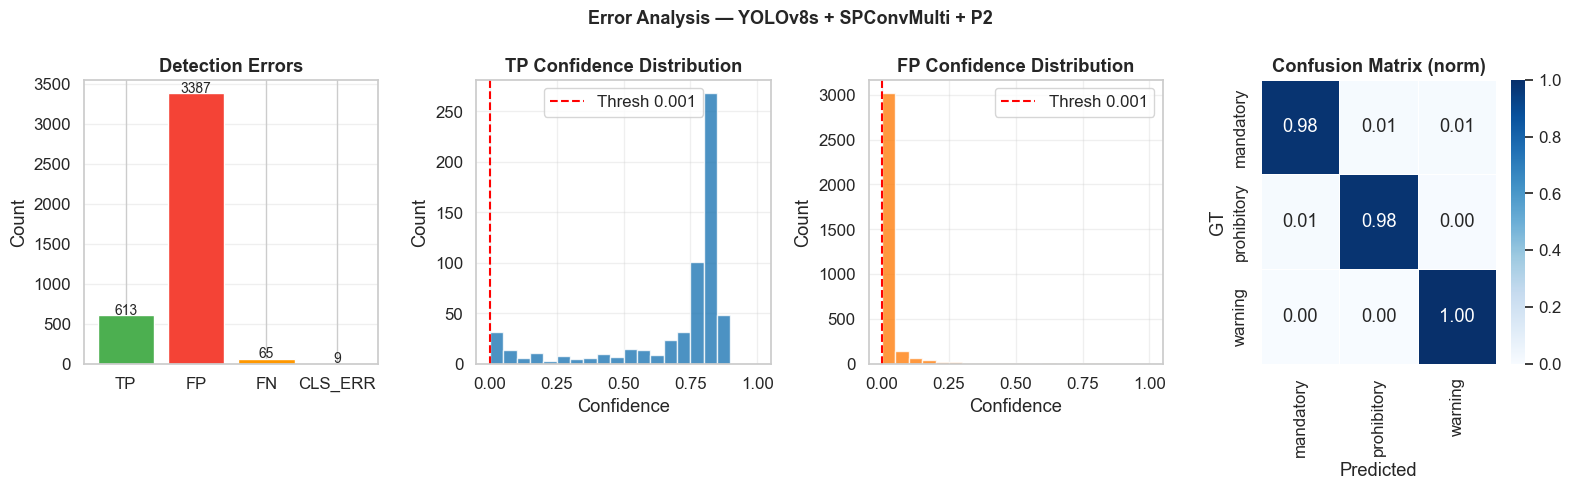

In [20]:
def parse_gt_label(lbl_path, img_w, img_h):
    boxes = []
    if not os.path.exists(lbl_path):
        return boxes
    with open(lbl_path) as f:
        for line in f:
            p = line.strip().split()
            if len(p) < 5:
                continue
            cls, cx, cy, bw, bh = int(p[0]), *map(float, p[1:5])
            x1 = int((cx - bw / 2) * img_w)
            y1 = int((cy - bh / 2) * img_h)
            x2 = int((cx + bw / 2) * img_w)
            y2 = int((cy + bh / 2) * img_h)
            boxes.append((cls, x1, y1, x2, y2))
    return boxes


def box_iou(b1, b2):
    ix1, iy1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    ix2, iy2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    a1 = (b1[2] - b1[0]) * (b1[3] - b1[1])
    a2 = (b2[2] - b2[0]) * (b2[3] - b2[1])
    return inter / (a1 + a2 - inter + 1e-6)


def classify_preds(result, gt_boxes, iou_thresh=0.5):
    preds = []
    if result.boxes:
        for b in result.boxes:
            x1, y1, x2, y2 = map(int, b.xyxy[0].tolist())
            preds.append((int(b.cls), float(b.conf), x1, y1, x2, y2))
    matched = set()
    tp = fp = cls_err = 0
    tp_c = []
    fp_c = []
    for pcls, pconf, px1, py1, px2, py2 in preds:
        best_iou, best_idx = 0, -1
        for gi, (gcls, gx1, gy1, gx2, gy2) in enumerate(gt_boxes):
            iou = box_iou((px1, py1, px2, py2), (gx1, gy1, gx2, gy2))
            if iou > best_iou:
                best_iou, best_idx = iou, gi
        if best_iou >= iou_thresh and best_idx not in matched:
            matched.add(best_idx)
            if pcls == gt_boxes[best_idx][0]:
                tp += 1
                tp_c.append(pconf)
            else:
                cls_err += 1
                fp_c.append(pconf)
        else:
            fp += 1
            fp_c.append(pconf)
    return {
        "TP": tp,
        "FP": fp,
        "FN": len(gt_boxes) - len(matched),
        "CLS_ERR": cls_err,
        "fp_confs": fp_c,
        "tp_confs": tp_c,
    }


MAX_VAL_IMGS = 300
all_imgs = sorted(
    glob.glob(str(VAL_IMG_DIR / "*.jpg")) + glob.glob(str(VAL_IMG_DIR / "*.png"))
)
eval_imgs = (
    np.random.default_rng(0)
    .choice(all_imgs, min(MAX_VAL_IMGS, len(all_imgs)), replace=False)
    .tolist()
)

model = YOLO(str(weights))
totals = {"TP": 0, "FP": 0, "FN": 0, "CLS_ERR": 0}
fp_confs_all = []
tp_confs_all = []
gt_cls_all = []
pred_cls_all = []

for img_path in eval_imgs:
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    stem = Path(img_path).stem
    gt = parse_gt_label(str(VAL_LBL_DIR / f"{stem}.txt"), w, h)
    result = model(
        img, conf=CONF_THRES, iou=IOU_THRES, imgsz=configs["imgsz"], verbose=False
    )[0]
    c = classify_preds(result, gt)
    for k in totals:
        totals[k] += c[k]
    fp_confs_all.extend(c["fp_confs"])
    tp_confs_all.extend(c["tp_confs"])
    # collect for confusion matrix
    preds_ = []
    if result.boxes:
        for b in result.boxes:
            x1, y1, x2, y2 = map(int, b.xyxy[0].tolist())
            preds_.append((int(b.cls), x1, y1, x2, y2))
    matched_ = set()
    for pcls, px1, py1, px2, py2 in preds_:
        best_iou, best_idx = 0, -1
        for gi, (gcls, gx1, gy1, gx2, gy2) in enumerate(gt):
            iou = box_iou((px1, py1, px2, py2), (gx1, gy1, gx2, gy2))
            if iou > best_iou:
                best_iou, best_idx = iou, gi
        if best_iou >= 0.5 and best_idx not in matched_:
            matched_.add(best_idx)
            gt_cls_all.append(gt[best_idx][0])
            pred_cls_all.append(pcls)

tp = totals["TP"]
fp = totals["FP"]
fn = totals["FN"]
ce = totals["CLS_ERR"]
total_pred = tp + fp + ce
total_gt = tp + fn + ce
prec = tp / (total_pred + 1e-6)
rec = tp / (total_gt + 1e-6)
f1 = 2 * prec * rec / (prec + rec + 1e-6)
print(f"TP={tp}  FP={fp}  FN={fn}  CLS_ERR={ce}")
print(f"Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# ── error bar ──────────────────────────────────────────────────────────
vals = [tp, fp, fn, ce]
labels_e = ["TP", "FP", "FN", "CLS_ERR"]
colors_e = ["#4CAF50", "#F44336", "#FF9800", "#9C27B0"]
axes[0].bar(labels_e, vals, color=colors_e, edgecolor="white")
for bar, v in zip(axes[0].patches, vals):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(v),
        ha="center",
        fontsize=10,
    )
axes[0].set_title("Detection Errors", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.3)

# ── TP confidence dist ─────────────────────────────────────────────────
if tp_confs_all:
    axes[1].hist(
        tp_confs_all,
        bins=20,
        range=(0, 1),
        color=PALETTE[0],
        edgecolor="white",
        alpha=0.8,
    )
    axes[1].axvline(
        CONF_THRES, color="red", linestyle="--", label=f"Thresh {CONF_THRES}"
    )
    axes[1].set_title("TP Confidence Distribution", fontweight="bold")
    axes[1].set_xlabel("Confidence")
    axes[1].set_ylabel("Count")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

# ── FP confidence dist ─────────────────────────────────────────────────
if fp_confs_all:
    axes[2].hist(
        fp_confs_all,
        bins=20,
        range=(0, 1),
        color=PALETTE[1],
        edgecolor="white",
        alpha=0.8,
    )
    axes[2].axvline(
        CONF_THRES, color="red", linestyle="--", label=f"Thresh {CONF_THRES}"
    )
    axes[2].set_title("FP Confidence Distribution", fontweight="bold")
    axes[2].set_xlabel("Confidence")
    axes[2].set_ylabel("Count")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

# ── confusion matrix ──────────────────────────────────────────────────
if gt_cls_all:
    cm = confusion_matrix(
        gt_cls_all, pred_cls_all, labels=list(range(NC)), normalize="true"
    )
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        linewidths=0.5,
        ax=axes[3],
    )
    axes[3].set_title("Confusion Matrix (norm)", fontweight="bold")
    axes[3].set_xlabel("Predicted")
    axes[3].set_ylabel("GT")

plt.suptitle(f"Error Analysis — {model_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(analysis_dir / "error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## Box Distributions

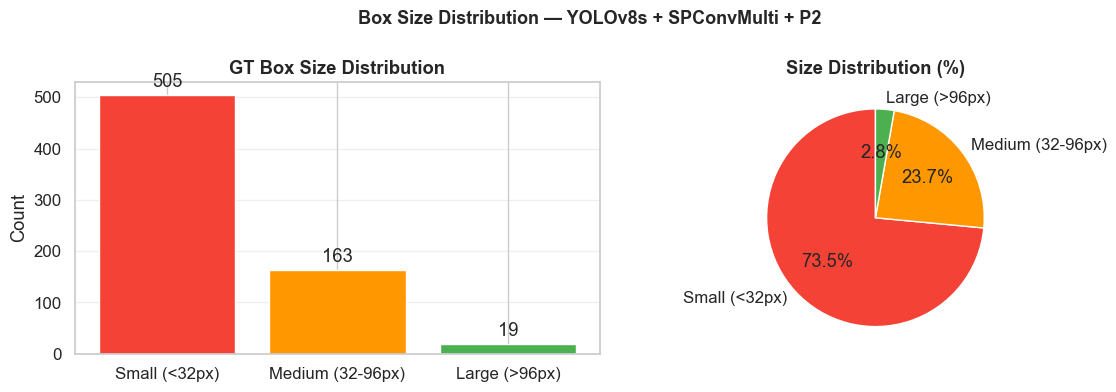

{'Small (<32px)': 505, 'Medium (32-96px)': 163, 'Large (>96px)': 19}


In [21]:
SIZE_BINS = [
    (0, 32, "Small (<32px)"),
    (32, 96, "Medium (32-96px)"),
    (96, 9999, "Large (>96px)"),
]


def size_cat(coords):
    _, x1, y1, x2, y2 = coords
    s = max(x2 - x1, y2 - y1)
    for lo, hi, name in SIZE_BINS:
        if lo <= s < hi:
            return name
    return "Large (>96px)"


size_counts = {name: 0 for _, _, name in SIZE_BINS}
for img_path in eval_imgs:
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    stem = Path(img_path).stem
    for gb in parse_gt_label(str(VAL_LBL_DIR / f"{stem}.txt"), w, h):
        size_counts[size_cat(gb)] += 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# count bar
colors_s = ["#F44336", "#FF9800", "#4CAF50"]
bars = axes[0].bar(
    size_counts.keys(), size_counts.values(), color=colors_s, edgecolor="white"
)
axes[0].bar_label(bars, padding=3)
axes[0].set_title("GT Box Size Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.3)

# pie
axes[1].pie(
    size_counts.values(),
    labels=size_counts.keys(),
    colors=colors_s,
    autopct="%1.1f%%",
    startangle=90,
)
axes[1].set_title("Size Distribution (%)", fontweight="bold")

plt.suptitle(f"Box Size Distribution — {model_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(analysis_dir / "box_size_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print(size_counts)


## Summary

In [22]:
summary = {
    'run'           : model_name,
    'mAP@0.5'       : round(map50_overall, 4),
    'mAP@0.5:0.95'  : round(map5095_overall, 4),
    'precision'     : round(val_model.box.mp, 4),
    'recall'        : round(val_model.box.mr, 4),
    'params_M'      : params_m,
    'flops_G'       : flops_g,
    'fps'           : fps,
    'latency_ms'    : lat,
    'TP'            : totals['TP'],
    'FP'            : totals['FP'],
    'FN'            : totals['FN'],
    'CLS_ERR'       : totals['CLS_ERR'],
}
summary.update({f'AP50_{c}': round(ap50[c],4) for c in CLASS_NAMES})

summary_df = pd.DataFrame([summary])
csv_out = analysis_dir / 'summary.csv'
summary_df.to_csv(csv_out, index=False)

output_files = sorted(analysis_dir.glob('*.png')) + [csv_out]
print(f'Saved {len(output_files)} files to {analysis_dir}:')
for f in output_files:
    print(f'  {f.name:45s} {f.stat().st_size//1024:4d} KB')

summary_df.T


Saved 9 files to runs\detect\YOLOv8s Traffic Detection\YOLOv8s + SPConvMulti + P2\train\post_analysis:
  box_size_dist.png                               72 KB
  detection_samples.png                         2535 KB
  error_analysis.png                             112 KB
  gradcam_multilayer.png                        4896 KB
  perclass_ap.png                                 61 KB
  summary_card.png                                33 KB
  training_curves.png                            163 KB
  val_curves.png                                 222 KB
  summary.csv                                      0 KB


,0
run,YOLOv8s + SPConvMulti + P2
mAP@0.5,0.8166
mAP@0.5:0.95,0.5322
precision,0.8696
recall,0.7739
params_M,4.76
flops_G,39.4
fps,108.1
latency_ms,9.25
TP,613
